In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from scipy.integrate import solve_ivp

## Heat Equation

In this notebook I will use solve_ivp to evolve forward the heat equation in 1D and 2D and plot the results respectively.  
I will learn how use solve_ivp for partial differential equations and also how to encode boundary conditions that themselves are functions.  

For our scenario, we will be assuming and infinitely thin rod of length $L$ where $u(x,t)$ will denote the temperature.
Our 1D heat equation is then

$$\frac{\partial u}{\partial t} = \alpha \dfrac{\partial^2 u}{\partial x^2}$$
Where $\alpha \left[ \frac{m^2}{s} \right]$ is the thermal diffusivity.

For a well posed problem, we will need both an initial condition and boundary conditions.  
The initial condition will need to take the form of an initial distribution represented by $u(x,0)$.  
We'll start with boundary conditions $u(0,t) = 0$ and $u(L,t) = 0$, enforcing the ends of our rod are always at zero temperature.
A good initial distribution might be 

$$u(x,0) = sin\left(\frac{\pi x}{L} \right) $$

as this immediately satisfies the boundary conditions.

We now apply a centered finite difference scheme to approximate our partial derivitives and create a large system of ODEs.

(50, 100)


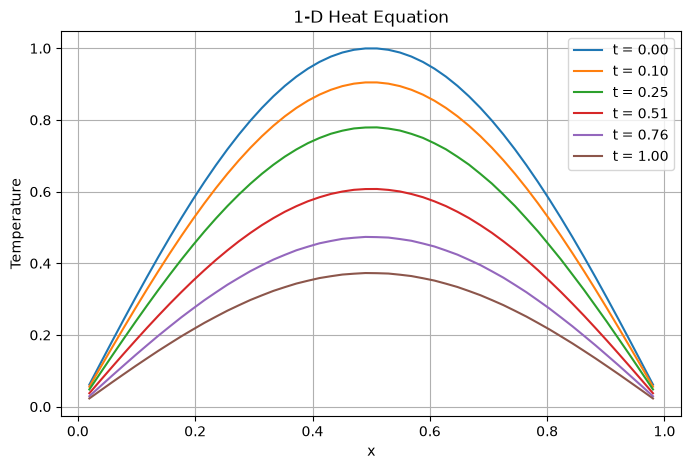

In [3]:
# --------------------------------------------------
# Physical parameters
# --------------------------------------------------

L = 1.0          # length of rod
alpha = 0.1      # thermal diffusivity

# --------------------------------------------------
# Spatial discretization
# --------------------------------------------------

N = 50                    # number of interior points
dx = L / (N + 1)

x = np.linspace(0, L, N + 2)

# We only integrate the interior points.
x_interior = x[1:-1] #sliced out the endpoints, this is also a numpy array.

# --------------------------------------------------
# Initial condition
# --------------------------------------------------
# Notice how we use the x_interior array making u0 an array of the inital temperature values of each interior point.
u0 = np.sin(np.pi * x_interior / L)

# --------------------------------------------------
# Define the ODE system
# --------------------------------------------------

def heat_equation(t, u):
    dudt = np.zeros_like(u) #new array

    # Interior finite-difference approximation
    dudt[0] = alpha * (
        -2*u[0] + u[1]
    ) / dx**2

    dudt[1:-1] = alpha * (
        u[:-2] - 2*u[1:-1] + u[2:]
    ) / dx**2

    dudt[-1] = alpha * (
        u[-2] - 2*u[-1]
    ) / dx**2

    return dudt

# --------------------------------------------------
# Time interval
# --------------------------------------------------

t_span = (0, 1)

# Times at which we want the solution
t_eval = np.linspace(0, 1, 100)

# --------------------------------------------------
# Solve
# --------------------------------------------------

solution = solve_ivp(
    heat_equation,
    t_span,
    u0,
    t_eval=t_eval
)

# --------------------------------------------------
# Plot the solution
# --------------------------------------------------

# The shape of the solution is a matrix with 50 rows (the x-positions), and 100 columns (the recoreded times), each element of this matrix is a temperature
print(solution.y.shape)

plt.figure(figsize=(8, 5))

for i in [0, 10, 25, 50, 75, 99]:
    plt.plot(
        x_interior,
        solution.y[:, i],
        label=f"t = {solution.t[i]:.2f}"
    )


plt.xlabel("x")
plt.ylabel("Temperature")
plt.title("1-D Heat Equation")
plt.legend()
plt.grid()
plt.show()


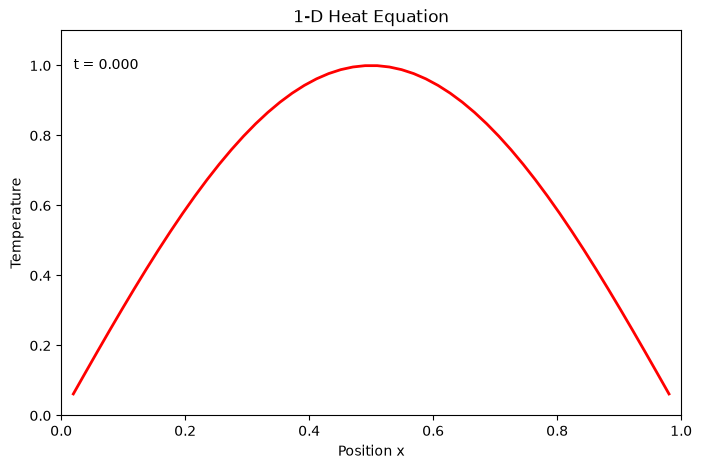

In [4]:
# --------------------------------------------------
# Plot Animation
# --------------------------------------------------

fig, ax = plt.subplots(figsize=(8, 5))

# Create the initial line
line, = ax.plot(
    x_interior,
    solution.y[:, 0],
    color="red",
    linewidth=2
)

# Set fixed axis limits
ax.set_xlim(0, L)
ax.set_ylim(0, 1.1)

ax.set_xlabel("Position x")
ax.set_ylabel("Temperature")
ax.set_title("1-D Heat Equation")

# Text showing the current time
time_text = ax.text(
    0.02, 0.90,
    "",
    transform=ax.transAxes
)


def update(frame):
    # Update the temperature curve
    line.set_ydata(solution.y[:, frame])

    # Update displayed time
    time_text.set_text(
        f"t = {solution.t[frame]:.3f}"
    )

    return line, time_text


animation = FuncAnimation(
    fig,
    update,
    frames=len(solution.t),
    interval=30,
    blit=True
)

plt.show()


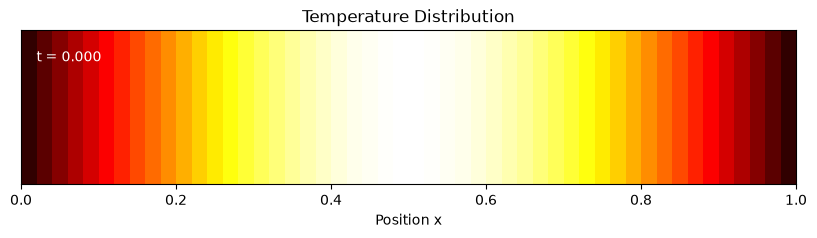

In [5]:
# --------------------------------------------------
# Rod Animation
# --------------------------------------------------

fig, ax = plt.subplots(figsize=(10, 2))

# Temperature image
temperature = solution.y[:, 0][np.newaxis, :]

image = ax.imshow(
    temperature,
    aspect="auto",
    cmap="hot",
    extent=[0, L, 0, 1],
    vmin=0,
    vmax=1
)

ax.set_xlabel("Position x")
ax.set_yticks([])
ax.set_title("Temperature Distribution")

time_text = ax.text(
    0.02,
    0.8,
    "",
    color="white",
    transform=ax.transAxes
)


def update(frame):
    temperature = solution.y[:, frame][np.newaxis, :]

    image.set_data(temperature)

    time_text.set_text(
        f"t = {solution.t[frame]:.3f}"
    )

    return image, time_text


animation = FuncAnimation(
    fig,
    update,
    frames=len(solution.t),
    interval=30,
    blit=True
)

plt.show()
